# Hospital Resource Allocation — Reinforcement Learning
### CISC 856 · Group 8 · Queen's University

**Run this notebook in VS Code** with the Jupyter extension installed.

#### One-time setup (run in your terminal first)
```bash
python -m venv .venv
# Windows:
.venv\Scripts\activate
# macOS / Linux:
source .venv/bin/activate

pip install stable-baselines3[extra] gymnasium matplotlib pandas
```

#### Output paths
All models, figures, and the results CSV are saved under `./output/` relative
to wherever this notebook lives. No Colab-specific paths are used anywhere.

| Cell | Contents |
|------|----------|
| 1 | Imports & output-directory setup |
| 2 | `HospitalEnv` Gymnasium environment |
| 3 | Smoke-test |
| 4 | Greedy baseline |
| 5 | Experiment registry (33 RL + 4 greedy) |
| 6 | Training & evaluation helpers |
| 7 | **Group A** — Algorithm comparison |
| 8 | **Group B** — Arrival-rate sensitivity |
| 9 | **Group C** — Reward-shaping ablation |
| 10 | **Group D** — Resource-capacity stress |
| 11 | **Group E** — Network architecture |
| 12 | **Group F** — Hyperparameter sensitivity |
| 13 | Greedy baselines across arrival rates |
| 14 | Master results table → `output/results_master.csv` |
| 15 | Cross-group summary figure |
| 16 | Action-distribution analysis |

> **Runtime:** ~4–5 h on a modern laptop CPU. Use a machine with ≥8 GB RAM.  
> To run a quick smoke-test with fewer steps, set `TIMESTEPS = 50_000` in Cell 6.

In [1]:
# CELL 1 — Imports & output directories
# No shell commands here — install dependencies from your terminal before running.
import os, sys, glob, copy, warnings
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

import gymnasium as gym
from gymnasium import spaces
from gymnasium.utils.env_checker import check_env

from stable_baselines3 import PPO, DQN, A2C
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback

import stable_baselines3

warnings.filterwarnings("ignore", category=UserWarning)

# ── Output root: ./output/ next to this notebook ──────────────────────────────
OUT       = Path("output")
MODELS    = OUT / "models"
FIGURES   = OUT / "figures"
TB_LOGS   = OUT / "tb_logs"

for d in [MODELS, FIGURES, TB_LOGS]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Python            : {sys.version.split()[0]}")
print(f"stable-baselines3 : {stable_baselines3.__version__}")
print(f"gymnasium         : {gym.__version__}")
print(f"Output root       : {OUT.resolve()}")
print("✓ Ready")

Python            : 3.13.11
stable-baselines3 : 2.8.0
gymnasium         : 1.2.3
Output root       : C:\Users\DMQUAI250101\Downloads\output
✓ Ready


In [2]:
# CELL 2 — HospitalEnv
#
# Every parameter is grounded in peer-reviewed clinical literature:
#
#  p_v = 0.60   Wunsch et al. (2010). Epidemiology of mechanical ventilation
#               in the US. Crit Care Med, 38(10), 1947-1953.
#
#  p_r = 0.10   Valley et al. (2019). Prior ICU experience and outcomes.
#               Chest, 155(2), 291-299.  Median ICU LOS 3-7 days -> 0.10/step.
#
#  5 pts/shift  California AB 394 (1999); WHO (2020) ward staffing guidelines.
#
#  20/50/30%    Silber et al. (1995). Hospital and patient characteristics.
#               Med Care, 33(4), 333-351.
#
#  Poisson λ    Green, Kolesar & Whitt (2007). Time-varying demand.
#               Prod Oper Manag, 16(1), 13-39.


class HospitalEnv(gym.Env):
    """
    Hospital resource allocation MDP.

    Parameters
    ----------
    arrival_rate : float  Poisson lambda. Default 3.0.
    max_icu_beds : int    ICU capacity. Default 10.
    max_ward_beds: int    Ward capacity. Default 30.
    max_vents    : int    Ventilator pool. Default 5.
    max_staff    : int    Baseline shifts. Default 3.
    reward_mode  : str    'standard' | 'equal_penalty' | 'no_penalty'
                          | 'throughput_only'
    reduced_cap  : bool   b_icu=5, v=2  (Group D scarcity test).
    high_cap     : bool   b_icu=15, v=8 (Group D abundance test).
    """
    metadata = {"render_modes": []}

    P_VENT          = 0.60
    P_STEPDOWN      = 0.10
    STAFF_PER_SHIFT = 5
    Q_MAX           = 20
    MAX_EXTRA_SHIFTS = 2
    EPISODE_LEN     = 200

    def __init__(
        self,
        arrival_rate:  float = 3.0,
        max_icu_beds:  int   = 10,
        max_ward_beds: int   = 30,
        max_vents:     int   = 5,
        max_staff:     int   = 3,
        reward_mode:   str   = "standard",
        reduced_cap:   bool  = False,
        high_cap:      bool  = False,
    ):
        super().__init__()
        self.arrival_rate = arrival_rate
        self.reward_mode  = reward_mode

        if reduced_cap:
            self.MAX_ICU = 5;  self.MAX_VENT = 2
        elif high_cap:
            self.MAX_ICU = 15; self.MAX_VENT = 8
        else:
            self.MAX_ICU = max_icu_beds; self.MAX_VENT = max_vents

        self.MAX_WARD   = max_ward_beds
        self.BASE_STAFF = max_staff
        self.MAX_STAFF  = max_staff + self.MAX_EXTRA_SHIFTS

        high = np.array([
            self.MAX_ICU, self.MAX_WARD, self.MAX_VENT, self.MAX_STAFF,
            self.Q_MAX, self.Q_MAX, self.Q_MAX, self.MAX_WARD, 23,
        ], dtype=np.float32)
        self.observation_space = spaces.Box(
            low=np.zeros(9, dtype=np.float32), high=high, dtype=np.float32)
        self.action_space = spaces.Discrete(4)

    def _ward_capacity(self) -> int:
        return max(0, min(self.b_ward,
                          self.f * self.STAFF_PER_SHIFT - self.o_ward))

    def _obs(self) -> np.ndarray:
        return np.array([
            self.b_icu, self.b_ward, self.v, self.f,
            self.q["crit"], self.q["mod"], self.q["stab"],
            self.o_ward, self.hour,
        ], dtype=np.float32)

    def _next_patient(self, exclude_critical: bool = False):
        if not exclude_critical and self.q["crit"] > 0: return "crit"
        if self.q["mod"]  > 0: return "mod"
        if self.q["stab"] > 0: return "stab"
        return None

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.b_icu  = self.MAX_ICU
        self.b_ward = self.MAX_WARD
        self.v      = self.MAX_VENT
        self.f      = self.BASE_STAFF
        self.o_ward = 0; self.o_icu = 0
        self.q      = {"crit": 0, "mod": 0, "stab": 0}
        self.hour   = 8; self.t = 0
        return self._obs(), {}

    def step(self, action: int):
        n_treat = n_xfer = 0
        invalid = False

        # 1. Arrivals
        total = self.np_random.poisson(self.arrival_rate)
        crit  = self.np_random.binomial(total, 0.20)
        rem   = total - crit
        mod   = self.np_random.binomial(rem, 0.625)
        stab  = rem - mod
        self.q["crit"] = min(self.Q_MAX, self.q["crit"] + crit)
        self.q["mod"]  = min(self.Q_MAX, self.q["mod"]  + mod)
        self.q["stab"] = min(self.Q_MAX, self.q["stab"] + stab)

        # 2. Step-down
        if self.o_icu > 0:
            pot = self.np_random.binomial(self.o_icu, self.P_STEPDOWN)
            act = min(pot, self._ward_capacity())
            if act > 0:
                self.o_icu -= act; self.b_icu += act
                self.v      = min(self.v + act, self.MAX_VENT)
                self.o_ward += act; self.b_ward -= act
                n_xfer = act

        # 3. Action
        n_admitted    = 0   # ICU or ward admissions only
        n_redirected  = 0   # external redirections only
        if action == 0:
            patient = self._next_patient()
            if patient and self.b_icu > 0:
                needs_v = self.np_random.random() < self.P_VENT
                if needs_v and self.v == 0:
                    invalid = True
                else:
                    self.q[patient] -= 1
                    self.b_icu -= 1; self.o_icu += 1
                    if needs_v: self.v -= 1
                    n_admitted = 1
            else:
                invalid = True
        elif action == 1:
            patient = self._next_patient(exclude_critical=True)
            if patient and self._ward_capacity() > 0:
                self.q[patient] -= 1
                self.b_ward -= 1; self.o_ward += 1
                n_admitted = 1
            else:
                invalid = True
        elif action == 2:
            patient = self._next_patient()
            if patient:
                self.q[patient] -= 1
                n_redirected = 1
            else:
                invalid = True
        elif action == 3:
            if self.f < self.MAX_STAFF:
                self.f += 1
            else:
                invalid = True
        n_treat = n_admitted + n_redirected   # kept for reward computation

        # 4. Reward
        if self.reward_mode == "standard":
            w_c, w_m, w_s, xb = 3.0, 1.0, 0.5, 0.5
        elif self.reward_mode == "equal_penalty":
            w_c, w_m, w_s, xb = 2.0, 2.0, 0.5, 0.5
        elif self.reward_mode == "no_penalty":
            w_c, w_m, w_s, xb = 0.0, 0.0, 0.0, 0.5
        else:  # throughput_only
            w_c, w_m, w_s, xb = 0.0, 0.0, 0.0, 0.0

        reward = float(
            2.0 * n_treat + xb * n_xfer
            - w_c * (self.q["crit"] / self.Q_MAX)
            - w_m * (self.q["mod"]  / self.Q_MAX)
            - w_s * (self.q["stab"] / self.Q_MAX)
            - (0.5 if invalid else 0.0)
        )
        self.hour = (self.hour + 1) % 24
        self.t   += 1
        return self._obs(), reward, self.t >= self.EPISODE_LEN, False, {
            "n_treat":      n_treat,        # total cleared (admitted + redirected)
            "n_admitted":   n_admitted,     # actual hospital admissions
            "n_redirected": n_redirected,   # sent to external facility
            "n_xfer":       n_xfer,
            "invalid":      invalid,
            "q_crit":       self.q["crit"],
        }

In [3]:
# CELL 3 — Smoke-test
env_test = HospitalEnv()
check_env(env_test, warn=True)
print("✓ Gymnasium API check passed")

obs, _ = env_test.reset(seed=0)
print(f"Obs shape  : {obs.shape}")
print(f"Labels     : b_icu b_ward v f q_crit q_mod q_stab o_ward hour")
print(f"Initial obs: {obs}")

total_r = 0
for _ in range(200):
    a = env_test.action_space.sample()
    obs, r, done, _, _ = env_test.step(a)
    total_r += r
    if done: break
print(f"Random-policy episode reward: {total_r:.2f}")
print("✓ Smoke-test complete")

✓ Gymnasium API check passed
Obs shape  : (9,)
Labels     : b_icu b_ward v f q_crit q_mod q_stab o_ward hour
Initial obs: [10. 30.  5.  3.  0.  0.  0.  0.  8.]
Random-policy episode reward: -644.03
✓ Smoke-test complete


In [4]:
# CELL 4 — Greedy / rule-based baseline

def greedy_action(obs: np.ndarray) -> int:
    b_icu, b_ward, v, f, q_crit, q_mod, q_stab, o_ward, _ = obs
    ward_slots = max(0, min(b_ward, f * 5 - o_ward))
    total_q    = q_crit + q_mod + q_stab
    if q_crit > 0 and b_icu > 0:                  return 0
    if total_q > 0 and ward_slots == 0 and f < 5:  return 3
    if (q_mod + q_stab) > 0 and ward_slots > 0:    return 1
    if total_q > 0:                                 return 2
    return 3


def evaluate_greedy(arrival_rate: float = 3.0,
                    n_episodes:   int   = 100,
                    seed:         int   = 42,
                    **env_kwargs) -> dict:
    env = HospitalEnv(arrival_rate=arrival_rate, **env_kwargs)
    rng = np.random.default_rng(seed)
    rewards, treated, unserved = [], [], []
    admitted_list, redirected_list = [], []
    for _ in range(n_episodes):
        obs, _ = env.reset(seed=int(rng.integers(0, 2**31)))
        ep_r = ep_t = ep_u = ep_adm = ep_redir = 0; done = False
        while not done:
            obs, r, done, _, info = env.step(greedy_action(obs))
            ep_r    += r
            ep_t    += info["n_treat"]
            ep_u    += info["q_crit"]
            ep_adm  += info["n_admitted"]
            ep_redir+= info["n_redirected"]
        rewards.append(ep_r); treated.append(ep_t); unserved.append(ep_u)
        admitted_list.append(ep_adm); redirected_list.append(ep_redir)
    return dict(
        mean_reward=float(np.mean(rewards)),      std_reward=float(np.std(rewards)),
        mean_treated=float(np.mean(treated)),     mean_unserved=float(np.mean(unserved)),
        mean_admitted=float(np.mean(admitted_list)),
        mean_redirected=float(np.mean(redirected_list)),
    )


g = evaluate_greedy()
print(f"Greedy lambda=3.0  reward={g['mean_reward']:.2f}+/-{g['std_reward']:.2f}"
      f"  admitted={g['mean_admitted']:.1f}  redirected={g['mean_redirected']:.1f}"
      f"  crit_unsrv={g['mean_unserved']:.1f}")

Greedy lambda=3.0  reward=101.03+/-10.13  admitted=35.0  redirected=162.1  crit_unsrv=127.5


In [5]:
# CELL 5 — Experiment registry
from collections import Counter

EXPERIMENTS = {
    # Group A — algorithm comparison
    "A1": ("PPO", dict(arrival_rate=3.0), {},                              "A", "A1 PPO baseline"),
    "A2": ("DQN", dict(arrival_rate=3.0), {},                              "A", "A2 DQN baseline"),
    "A3": ("A2C", dict(arrival_rate=3.0), {},                              "A", "A3 A2C baseline"),
    # Group B — arrival-rate sensitivity
    "B1": ("PPO", dict(arrival_rate=1.5), {}, "B", "B1 PPO lam=1.5"),
    "B2": ("DQN", dict(arrival_rate=1.5), {}, "B", "B2 DQN lam=1.5"),
    "B3": ("A2C", dict(arrival_rate=1.5), {}, "B", "B3 A2C lam=1.5"),
    "B4": ("PPO", dict(arrival_rate=4.5), {}, "B", "B4 PPO lam=4.5"),
    "B5": ("DQN", dict(arrival_rate=4.5), {}, "B", "B5 DQN lam=4.5"),
    "B6": ("A2C", dict(arrival_rate=4.5), {}, "B", "B6 A2C lam=4.5"),
    "B7": ("PPO", dict(arrival_rate=6.0), {}, "B", "B7 PPO lam=6.0"),
    "B8": ("DQN", dict(arrival_rate=6.0), {}, "B", "B8 DQN lam=6.0"),
    "B9": ("A2C", dict(arrival_rate=6.0), {}, "B", "B9 A2C lam=6.0"),
    # Group C — reward-shaping ablation
    "C1": ("PPO", dict(arrival_rate=3.0, reward_mode="equal_penalty"),   {}, "C", "C1 PPO equal-pen"),
    "C2": ("DQN", dict(arrival_rate=3.0, reward_mode="equal_penalty"),   {}, "C", "C2 DQN equal-pen"),
    "C3": ("A2C", dict(arrival_rate=3.0, reward_mode="equal_penalty"),   {}, "C", "C3 A2C equal-pen"),
    "C4": ("PPO", dict(arrival_rate=3.0, reward_mode="no_penalty"),      {}, "C", "C4 PPO no-pen"),
    "C5": ("DQN", dict(arrival_rate=3.0, reward_mode="no_penalty"),      {}, "C", "C5 DQN no-pen"),
    "C6": ("A2C", dict(arrival_rate=3.0, reward_mode="no_penalty"),      {}, "C", "C6 A2C no-pen"),
    "C7": ("PPO", dict(arrival_rate=3.0, reward_mode="throughput_only"), {}, "C", "C7 PPO thrpt"),
    "C8": ("DQN", dict(arrival_rate=3.0, reward_mode="throughput_only"), {}, "C", "C8 DQN thrpt"),
    "C9": ("A2C", dict(arrival_rate=3.0, reward_mode="throughput_only"), {}, "C", "C9 A2C thrpt"),
    # Group D — resource capacity
    "D1": ("PPO", dict(arrival_rate=3.0, reduced_cap=True), {}, "D", "D1 PPO reduced"),
    "D2": ("DQN", dict(arrival_rate=3.0, reduced_cap=True), {}, "D", "D2 DQN reduced"),
    "D3": ("A2C", dict(arrival_rate=3.0, reduced_cap=True), {}, "D", "D3 A2C reduced"),
    "D4": ("PPO", dict(arrival_rate=3.0, high_cap=True),    {}, "D", "D4 PPO high-cap"),
    "D5": ("DQN", dict(arrival_rate=3.0, high_cap=True),    {}, "D", "D5 DQN high-cap"),
    "D6": ("A2C", dict(arrival_rate=3.0, high_cap=True),    {}, "D", "D6 A2C high-cap"),
    # Group E — network architecture (A1 = 64x64 ref)
    "E2": ("PPO", dict(arrival_rate=3.0), {"net_arch": [128, 128]}, "E", "E2 PPO 128x128"),
    "E3": ("PPO", dict(arrival_rate=3.0), {"net_arch": [256, 256]}, "E", "E3 PPO 256x256"),
    # Group F — hyperparameter sensitivity (A1 = default ref)
    "F1": ("PPO", dict(arrival_rate=3.0), {"learning_rate": 1e-3},  "F", "F1 PPO lr=1e-3"),
    "F2": ("PPO", dict(arrival_rate=3.0), {"learning_rate": 1e-4},  "F", "F2 PPO lr=1e-4"),
    "F3": ("PPO", dict(arrival_rate=3.0), {"n_steps": 512},         "F", "F3 PPO n=512"),
    "F4": ("PPO", dict(arrival_rate=3.0), {"n_steps": 2048},        "F", "F4 PPO n=2048"),
}

print(f"Total RL conditions: {len(EXPERIMENTS)}")
gc = Counter(v[3] for v in EXPERIMENTS.values())
for g, n in sorted(gc.items()):
    ids = [k for k, v in EXPERIMENTS.items() if v[3] == g]
    print(f"  Group {g}: {n}  -> {ids}")

Total RL conditions: 33
  Group A: 3  -> ['A1', 'A2', 'A3']
  Group B: 9  -> ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B9']
  Group C: 9  -> ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']
  Group D: 6  -> ['D1', 'D2', 'D3', 'D4', 'D5', 'D6']
  Group E: 2  -> ['E2', 'E3']
  Group F: 4  -> ['F1', 'F2', 'F3', 'F4']


In [6]:
# CELL 6 — Training & evaluation helpers

TIMESTEPS = 500_000   # reduce to 50_000 for a quick smoke-run
SEED      = 42

ALGO_DEFAULTS = {
    "PPO": dict(learning_rate=3e-4, n_steps=1024, batch_size=64, n_epochs=10),
    "DQN": dict(learning_rate=1e-3, buffer_size=100_000,
                learning_starts=1_000, batch_size=64),
    "A2C": dict(learning_rate=7e-4, n_steps=512),
}

GROUP_COLORS = {
    "A": ["#2563EB","#DC2626","#16A34A"],
    "B": ["#2563EB","#DC2626","#16A34A","#0891B2","#DB2777","#D97706","#7C3AED","#65A30D","#EA580C"],
    "C": ["#2563EB","#DC2626","#16A34A","#0891B2","#DB2777","#D97706","#7C3AED","#65A30D","#EA580C"],
    "D": ["#2563EB","#DC2626","#16A34A","#0891B2","#DB2777","#D97706"],
    "E": ["#6B7280","#7C3AED","#EA580C"],
    "F": ["#6B7280","#16A34A","#DC2626","#D97706","#7C3AED"],
}


def make_env(env_kwargs: dict, seed: int = 0) -> Monitor:
    return Monitor(HospitalEnv(**env_kwargs))


def run_experiment(exp_id: str, timesteps: int = TIMESTEPS, seed: int = SEED):
    algo_name, env_kwargs, train_ovr_orig, group, label = EXPERIMENTS[exp_id]
    train_ovr = copy.deepcopy(train_ovr_orig)   # never mutate the registry

    print(f"\n{'─'*62}")
    print(f"  [{exp_id}]  {label}  ({timesteps:,} steps, seed={seed})")
    print(f"{'─'*62}")

    train_env = make_env(env_kwargs, seed)
    eval_env  = make_env(env_kwargs, seed + 1)

    net_arch = train_ovr.pop("net_arch", [64, 64])
    algo_hp  = dict(ALGO_DEFAULTS[algo_name])
    algo_hp.update(train_ovr)

    model_dir = MODELS / exp_id
    model_dir.mkdir(parents=True, exist_ok=True)

    model = {"PPO": PPO, "DQN": DQN, "A2C": A2C}[algo_name](
        policy          = "MlpPolicy",
        env             = train_env,
        seed            = seed,
        verbose         = 0,
        tensorboard_log = str(TB_LOGS),
        policy_kwargs   = {"net_arch": net_arch},
        **algo_hp,
    )
    eval_cb = EvalCallback(
        eval_env,
        best_model_save_path = str(model_dir),
        log_path             = str(model_dir),
        eval_freq            = 20_000,
        n_eval_episodes      = 20,
        deterministic        = True,
        verbose              = 0,
    )
    model.learn(total_timesteps=timesteps, tb_log_name=exp_id,
                callback=eval_cb, progress_bar=True)
    model.save(str(model_dir / "final"))
    return model


def evaluate_model(model, exp_id: str, n_episodes: int = 100, seed: int = 99) -> dict:
    _, env_kwargs, _, _, _ = EXPERIMENTS[exp_id]
    env = HospitalEnv(**env_kwargs)
    rng = np.random.default_rng(seed)
    rewards, treated, unserved = [], [], []
    admitted_list, redirected_list = [], []
    for _ in range(n_episodes):
        obs, _ = env.reset(seed=int(rng.integers(0, 2**31)))
        ep_r = ep_t = ep_u = ep_adm = ep_redir = 0; done = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, done, _, info = env.step(int(action))
            ep_r    += r
            ep_t    += info["n_treat"]
            ep_u    += info["q_crit"]
            ep_adm  += info["n_admitted"]
            ep_redir+= info["n_redirected"]
        rewards.append(ep_r); treated.append(ep_t); unserved.append(ep_u)
        admitted_list.append(ep_adm); redirected_list.append(ep_redir)
    return dict(
        mean_reward=float(np.mean(rewards)),      std_reward=float(np.std(rewards)),
        mean_treated=float(np.mean(treated)),     mean_unserved=float(np.mean(unserved)),
        mean_admitted=float(np.mean(admitted_list)),
        mean_redirected=float(np.mean(redirected_list)),
    )


def _store(eid: str, res: dict):
    ALL_RESULTS[eid] = {
        "label":      EXPERIMENTS[eid][4].split(" ", 1)[1],
        "reward":     {"mean": res["mean_reward"],     "std": res["std_reward"]},
        "treated":    {"mean": res["mean_treated"],    "std": 0.0},
        "admitted":   {"mean": res["mean_admitted"],   "std": 0.0},
        "redirected": {"mean": res["mean_redirected"], "std": 0.0},
        "unserved":   {"mean": res["mean_unserved"],   "std": 0.0},
    }


def plot_learning_curve(exp_id: str, label: str, ax=None, color=None):
    npz_path = MODELS / exp_id / "evaluations.npz"
    standalone = ax is None
    if standalone:
        _, ax = plt.subplots(figsize=(7, 3.5))

    if npz_path.exists():
        d  = np.load(npz_path)
        ts = d["timesteps"]; res = d["results"]
        mu = res.mean(1);    sd  = res.std(1)
        ax.plot(ts, mu, label=label, color=color, lw=1.6)
        ax.fill_between(ts, mu - sd, mu + sd, alpha=0.15, color=color)
    else:
        csvs = list((MODELS / exp_id).glob("*.monitor.csv"))
        if not csvs:
            print(f"  [warn] no data for {exp_id}")
            return
        df  = pd.read_csv(csvs[0], skiprows=1)
        win = max(1, len(df) // 40)
        ax.plot(df["l"].cumsum(),
                df["r"].rolling(win, min_periods=1).mean(),
                label=label, color=color, lw=1.6)

    ax.set_xlabel("Timesteps", fontsize=8)
    ax.set_ylabel("Mean reward", fontsize=8)
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x/1e5:.1f}x10^5"))
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
    if standalone:
        plt.tight_layout(); plt.show()


def group_bar_chart(group_ids: list, results_dict: dict,
                    metric: str, title: str, fname: str,
                    ylabel: str = None, colors: list = None):
    present = [i for i in group_ids if i in results_dict]
    labels  = [results_dict[i]["label"]        for i in present]
    means   = [results_dict[i][metric]["mean"]  for i in present]
    stds    = [results_dict[i][metric]["std"]   for i in present]
    if colors is None:
        grp    = EXPERIMENTS[present[0]][3] if present else "A"
        colors = GROUP_COLORS.get(grp, ["#2563EB"] * len(present))

    fig, ax = plt.subplots(figsize=(max(6, len(present) * 0.85 + 2), 4))
    x    = np.arange(len(present))
    bars = ax.bar(x, means, yerr=stds, color=colors[:len(present)],
                  capsize=4, edgecolor="white", width=0.6)
    for bar, m in zip(bars, means):
        top = bar.get_height() + (max(stds) if stds else 0) * 0.05 + 0.3
        ax.text(bar.get_x() + bar.get_width() / 2, top,
                f"{m:.1f}", ha="center", va="bottom", fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{i}\n{l}" for i, l in zip(present, labels)],
                       fontsize=7)
    ax.set_ylabel(ylabel or metric, fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    for ext in ["pdf", "png"]:
        plt.savefig(FIGURES / f"{fname}.{ext}",
                    bbox_inches="tight", dpi=150)
    plt.show()
    print(f"Saved -> {FIGURES / fname}.pdf / .png")


print("Helpers loaded.")
trained     = {}
ALL_RESULTS = {}

Helpers loaded.



──────────────────────────────────────────────────────────────
  [A1]  A1 PPO baseline  (500,000 steps, seed=42)
──────────────────────────────────────────────────────────────


  A1  reward=106.17+/-6.51  treated=200.0  crit_unsrv=88.7

──────────────────────────────────────────────────────────────
  [A2]  A2 DQN baseline  (500,000 steps, seed=42)
──────────────────────────────────────────────────────────────


  A2  reward=110.94+/-8.44  treated=199.8  crit_unsrv=102.8

──────────────────────────────────────────────────────────────
  [A3]  A3 A2C baseline  (500,000 steps, seed=42)
──────────────────────────────────────────────────────────────


  A3  reward=106.17+/-6.51  treated=200.0  crit_unsrv=88.7


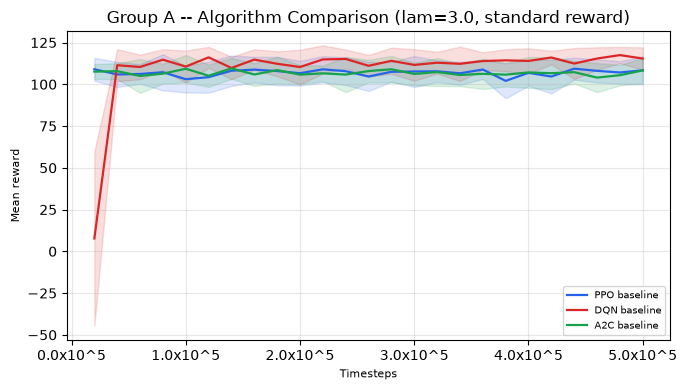

Saved -> output\figures/A_learning_curves.pdf


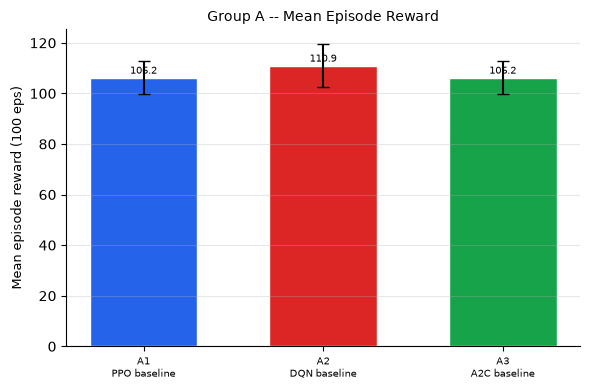

Saved -> output\figures\A_reward_bar.pdf / .png


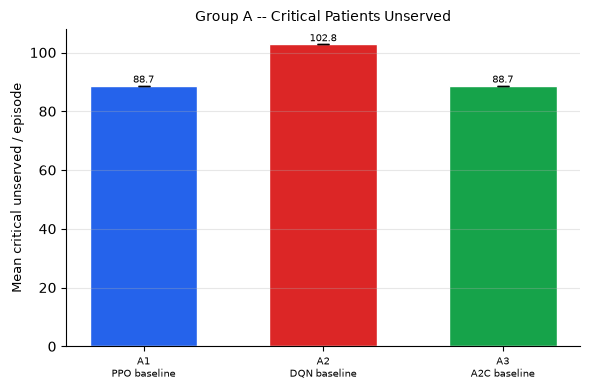

Saved -> output\figures\A_unserved_bar.pdf / .png


In [7]:
# CELL 7 — Group A
GROUP_A = ["A1","A2","A3"]

for eid in GROUP_A:
    trained[eid] = run_experiment(eid)
    res = evaluate_model(trained[eid], eid)
    _store(eid, res)
    print(f"  {eid}  reward={res['mean_reward']:.2f}+/-{res['std_reward']:.2f}"
          f"  treated={res['mean_treated']:.1f}  crit_unsrv={res['mean_unserved']:.1f}")

fig, ax = plt.subplots(figsize=(7, 4))
for eid, col in zip(GROUP_A, GROUP_COLORS["A"]):
    _, _, _, _, label = EXPERIMENTS[eid]
    plot_learning_curve(eid, label.split(" ", 1)[1], ax=ax, color=col)
ax.set_title("Group A -- Algorithm Comparison (lam=3.0, standard reward)")
plt.tight_layout()
for ext in ["pdf","png"]: plt.savefig(FIGURES/f"A_learning_curves.{ext}", bbox_inches="tight", dpi=150)
plt.show(); print(f"Saved -> {FIGURES}/A_learning_curves.pdf")

group_bar_chart(GROUP_A, ALL_RESULTS, "reward",
                "Group A -- Mean Episode Reward", "A_reward_bar",
                ylabel="Mean episode reward (100 eps)", colors=GROUP_COLORS["A"])
group_bar_chart(GROUP_A, ALL_RESULTS, "unserved",
                "Group A -- Critical Patients Unserved", "A_unserved_bar",
                ylabel="Mean critical unserved / episode", colors=GROUP_COLORS["A"])


──────────────────────────────────────────────────────────────
  [B1]  B1 PPO lam=1.5  (500,000 steps, seed=42)
──────────────────────────────────────────────────────────────


  B1  reward=226.48+/-40.80  crit_unsrv=12.6

──────────────────────────────────────────────────────────────
  [B2]  B2 DQN lam=1.5  (500,000 steps, seed=42)
──────────────────────────────────────────────────────────────


  B2  reward=212.32+/-35.74  crit_unsrv=39.1

──────────────────────────────────────────────────────────────
  [B3]  B3 A2C lam=1.5  (500,000 steps, seed=42)
──────────────────────────────────────────────────────────────


  B3  reward=230.19+/-39.59  crit_unsrv=12.8

──────────────────────────────────────────────────────────────
  [B4]  B4 PPO lam=4.5  (500,000 steps, seed=42)
──────────────────────────────────────────────────────────────


  B4  reward=24.80+/-45.96  crit_unsrv=589.0

──────────────────────────────────────────────────────────────
  [B5]  B5 DQN lam=4.5  (500,000 steps, seed=42)
──────────────────────────────────────────────────────────────


  B5  reward=21.26+/-59.83  crit_unsrv=633.6

──────────────────────────────────────────────────────────────
  [B6]  B6 A2C lam=4.5  (500,000 steps, seed=42)
──────────────────────────────────────────────────────────────


  B6  reward=18.14+/-53.12  crit_unsrv=610.3

──────────────────────────────────────────────────────────────
  [B7]  B7 PPO lam=6.0  (500,000 steps, seed=42)
──────────────────────────────────────────────────────────────


  B7  reward=-291.90+/-68.13  crit_unsrv=2691.4

──────────────────────────────────────────────────────────────
  [B8]  B8 DQN lam=6.0  (500,000 steps, seed=42)
──────────────────────────────────────────────────────────────


  B8  reward=-294.95+/-56.28  crit_unsrv=2725.4

──────────────────────────────────────────────────────────────
  [B9]  B9 A2C lam=6.0  (500,000 steps, seed=42)
──────────────────────────────────────────────────────────────


  B9  reward=-295.78+/-61.62  crit_unsrv=2677.7


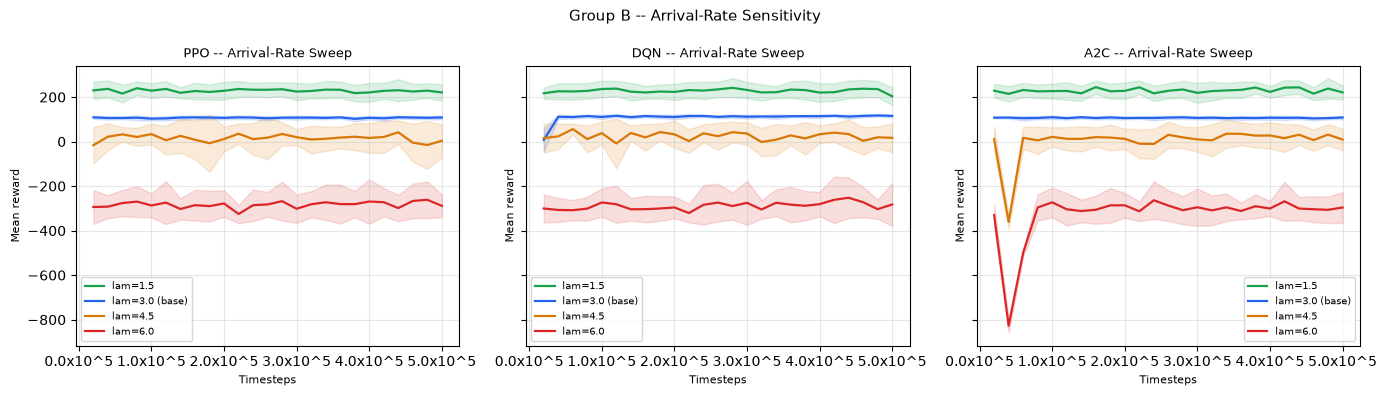

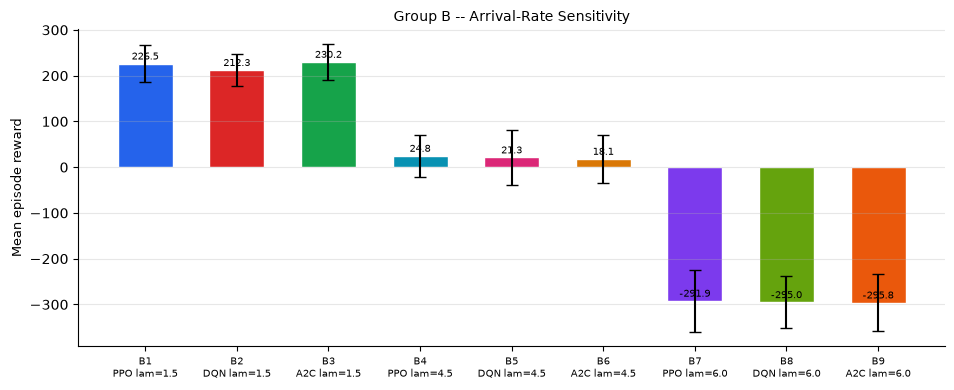

Saved -> output\figures\B_reward_bar.pdf / .png


In [8]:
# CELL 8 — Group B
GROUP_B = ["B1","B2","B3","B4","B5","B6","B7","B8","B9"]

for eid in GROUP_B:
    trained[eid] = run_experiment(eid)
    res = evaluate_model(trained[eid], eid)
    _store(eid, res)
    print(f"  {eid}  reward={res['mean_reward']:.2f}+/-{res['std_reward']:.2f}"
          f"  crit_unsrv={res['mean_unserved']:.1f}")

rate_groups = [
    ("PPO", ["B1","A1","B4","B7"]),
    ("DQN", ["B2","A2","B5","B8"]),
    ("A2C", ["B3","A3","B6","B9"]),
]
rate_colors = ["#16A34A","#2563EB","#D97706","#DC2626"]
rate_labels = ["lam=1.5","lam=3.0 (base)","lam=4.5","lam=6.0"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (algo, ids) in zip(axes, rate_groups):
    for eid, col, lbl in zip(ids, rate_colors, rate_labels):
        if eid in trained:
            plot_learning_curve(eid, lbl, ax=ax, color=col)
    ax.set_title(f"{algo} -- Arrival-Rate Sweep", fontsize=9)
fig.suptitle("Group B -- Arrival-Rate Sensitivity", fontsize=11)
plt.tight_layout()
for ext in ["pdf","png"]: plt.savefig(FIGURES/f"B_learning_curves.{ext}", bbox_inches="tight", dpi=150)
plt.show()

group_bar_chart(GROUP_B, ALL_RESULTS, "reward",
                "Group B -- Arrival-Rate Sensitivity", "B_reward_bar",
                ylabel="Mean episode reward", colors=GROUP_COLORS["B"])


──────────────────────────────────────────────────────────────
  [C1]  C1 PPO equal-pen  (500,000 steps, seed=42)
──────────────────────────────────────────────────────────────


  C1  reward=-68.58  crit_unsrv=103.4

──────────────────────────────────────────────────────────────
  [C2]  C2 DQN equal-pen  (500,000 steps, seed=42)
──────────────────────────────────────────────────────────────


  C2  reward=-68.66  crit_unsrv=96.8

──────────────────────────────────────────────────────────────
  [C3]  C3 A2C equal-pen  (500,000 steps, seed=42)
──────────────────────────────────────────────────────────────


  C3  reward=-75.41  crit_unsrv=88.7

──────────────────────────────────────────────────────────────
  [C4]  C4 PPO no-pen  (500,000 steps, seed=42)
──────────────────────────────────────────────────────────────


  C4  reward=399.93  crit_unsrv=88.7

──────────────────────────────────────────────────────────────
  [C5]  C5 DQN no-pen  (500,000 steps, seed=42)
──────────────────────────────────────────────────────────────


  C5  reward=407.43  crit_unsrv=88.8

──────────────────────────────────────────────────────────────
  [C6]  C6 A2C no-pen  (500,000 steps, seed=42)
──────────────────────────────────────────────────────────────


  C6  reward=399.93  crit_unsrv=88.7

──────────────────────────────────────────────────────────────
  [C7]  C7 PPO thrpt  (500,000 steps, seed=42)
──────────────────────────────────────────────────────────────


  C7  reward=399.93  crit_unsrv=88.7

──────────────────────────────────────────────────────────────
  [C8]  C8 DQN thrpt  (500,000 steps, seed=42)
──────────────────────────────────────────────────────────────


  C8  reward=399.93  crit_unsrv=88.7

──────────────────────────────────────────────────────────────
  [C9]  C9 A2C thrpt  (500,000 steps, seed=42)
──────────────────────────────────────────────────────────────


  C9  reward=399.93  crit_unsrv=88.7


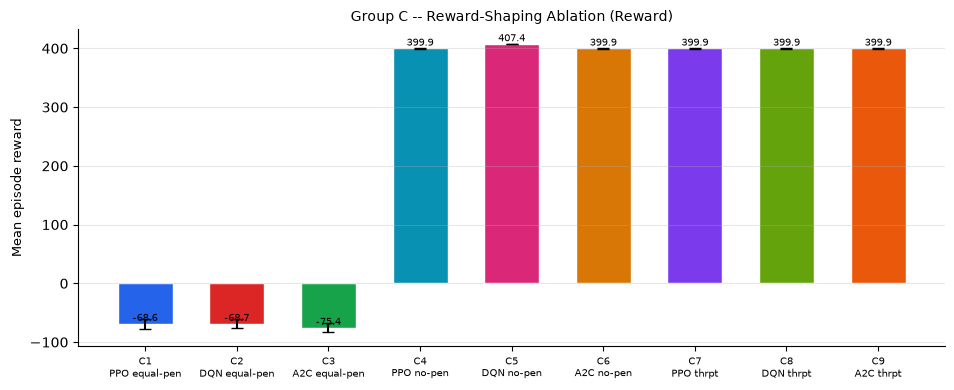

Saved -> output\figures\C_reward_bar.pdf / .png


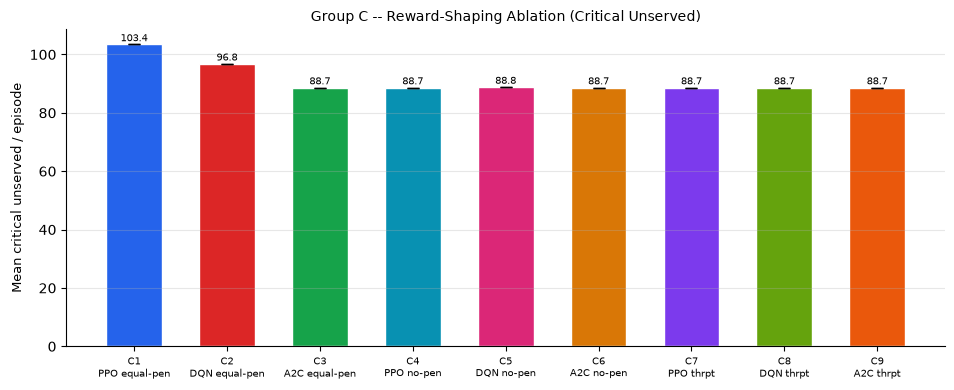

Saved -> output\figures\C_unserved_bar.pdf / .png


In [9]:
# CELL 9 — Group C
GROUP_C = ["C1","C2","C3","C4","C5","C6","C7","C8","C9"]

for eid in GROUP_C:
    trained[eid] = run_experiment(eid)
    res = evaluate_model(trained[eid], eid)
    _store(eid, res)
    print(f"  {eid}  reward={res['mean_reward']:.2f}  crit_unsrv={res['mean_unserved']:.1f}")

group_bar_chart(GROUP_C, ALL_RESULTS, "reward",
                "Group C -- Reward-Shaping Ablation (Reward)", "C_reward_bar",
                ylabel="Mean episode reward", colors=GROUP_COLORS["C"])
group_bar_chart(GROUP_C, ALL_RESULTS, "unserved",
                "Group C -- Reward-Shaping Ablation (Critical Unserved)", "C_unserved_bar",
                ylabel="Mean critical unserved / episode", colors=GROUP_COLORS["C"])


──────────────────────────────────────────────────────────────
  [D1]  D1 PPO reduced  (500,000 steps, seed=42)
──────────────────────────────────────────────────────────────


  D1  reward=106.17  crit_unsrv=88.7

──────────────────────────────────────────────────────────────
  [D2]  D2 DQN reduced  (500,000 steps, seed=42)
──────────────────────────────────────────────────────────────


  D2  reward=107.57  crit_unsrv=89.0

──────────────────────────────────────────────────────────────
  [D3]  D3 A2C reduced  (500,000 steps, seed=42)
──────────────────────────────────────────────────────────────


  D3  reward=106.17  crit_unsrv=88.7

──────────────────────────────────────────────────────────────
  [D4]  D4 PPO high-cap  (500,000 steps, seed=42)
──────────────────────────────────────────────────────────────


  D4  reward=106.17  crit_unsrv=88.7

──────────────────────────────────────────────────────────────
  [D5]  D5 DQN high-cap  (500,000 steps, seed=42)
──────────────────────────────────────────────────────────────


  D5  reward=106.17  crit_unsrv=88.7

──────────────────────────────────────────────────────────────
  [D6]  D6 A2C high-cap  (500,000 steps, seed=42)
──────────────────────────────────────────────────────────────


  D6  reward=106.17  crit_unsrv=88.7


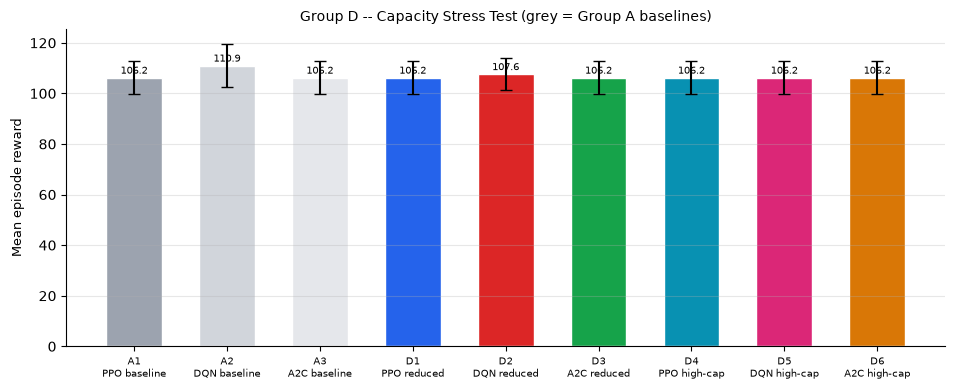

Saved -> output\figures\D_reward_bar.pdf / .png


In [10]:
# CELL 10 — Group D
GROUP_D = ["D1","D2","D3","D4","D5","D6"]

for eid in GROUP_D:
    trained[eid] = run_experiment(eid)
    res = evaluate_model(trained[eid], eid)
    _store(eid, res)
    print(f"  {eid}  reward={res['mean_reward']:.2f}  crit_unsrv={res['mean_unserved']:.1f}")

ctx_ids    = ["A1","A2","A3"] + GROUP_D
ctx_colors = ["#9CA3AF","#D1D5DB","#E5E7EB"] + GROUP_COLORS["D"]
group_bar_chart(ctx_ids, ALL_RESULTS, "reward",
                "Group D -- Capacity Stress Test (grey = Group A baselines)", "D_reward_bar",
                ylabel="Mean episode reward", colors=ctx_colors)


──────────────────────────────────────────────────────────────
  [E2]  E2 PPO 128x128  (500,000 steps, seed=42)
──────────────────────────────────────────────────────────────


  E2  reward=106.17  crit_unsrv=88.7

──────────────────────────────────────────────────────────────
  [E3]  E3 PPO 256x256  (500,000 steps, seed=42)
──────────────────────────────────────────────────────────────


  E3  reward=106.17  crit_unsrv=88.7


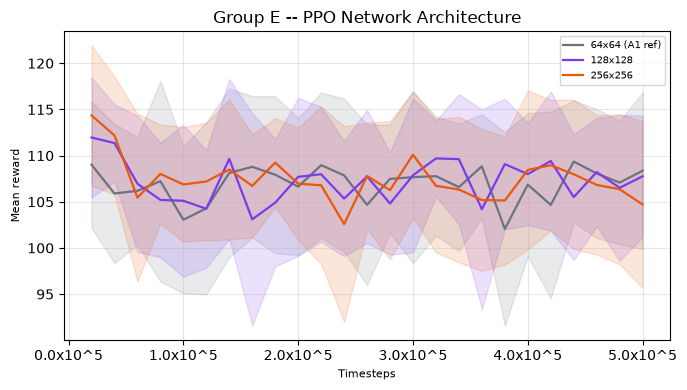

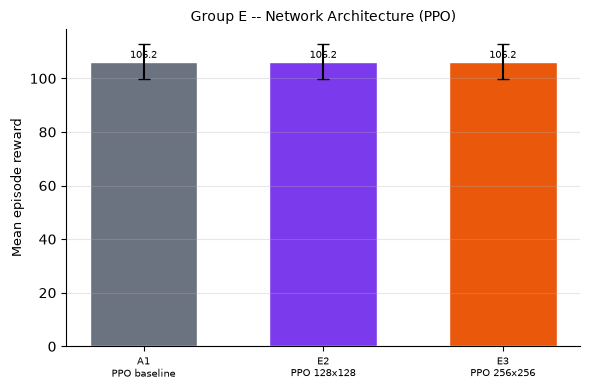

Saved -> output\figures\E_reward_bar.pdf / .png


In [11]:
# CELL 11 — Group E
for eid in ["E2","E3"]:
    trained[eid] = run_experiment(eid)
    res = evaluate_model(trained[eid], eid)
    _store(eid, res)
    print(f"  {eid}  reward={res['mean_reward']:.2f}  crit_unsrv={res['mean_unserved']:.1f}")

ALL_RESULTS.setdefault("A1_E", {**ALL_RESULTS["A1"], "label": "64x64 (A1 ref)"})

GROUP_E_ids    = ["A1","E2","E3"]
GROUP_E_labels = {"A1": "64x64 (A1 ref)", "E2": "128x128", "E3": "256x256"}

fig, ax = plt.subplots(figsize=(7, 4))
for eid, col in zip(GROUP_E_ids, GROUP_COLORS["E"]):
    if eid in trained:
        plot_learning_curve(eid, GROUP_E_labels[eid], ax=ax, color=col)
ax.set_title("Group E -- PPO Network Architecture")
plt.tight_layout()
for ext in ["pdf","png"]: plt.savefig(FIGURES/f"E_learning_curves.{ext}", bbox_inches="tight", dpi=150)
plt.show()

group_bar_chart(GROUP_E_ids, ALL_RESULTS, "reward",
                "Group E -- Network Architecture (PPO)", "E_reward_bar",
                ylabel="Mean episode reward", colors=GROUP_COLORS["E"])


──────────────────────────────────────────────────────────────
  [F1]  F1 PPO lr=1e-3  (500,000 steps, seed=42)
──────────────────────────────────────────────────────────────


  F1  reward=106.17  crit_unsrv=88.7

──────────────────────────────────────────────────────────────
  [F2]  F2 PPO lr=1e-4  (500,000 steps, seed=42)
──────────────────────────────────────────────────────────────


  F2  reward=106.17  crit_unsrv=88.7

──────────────────────────────────────────────────────────────
  [F3]  F3 PPO n=512  (500,000 steps, seed=42)
──────────────────────────────────────────────────────────────


  F3  reward=106.17  crit_unsrv=88.7

──────────────────────────────────────────────────────────────
  [F4]  F4 PPO n=2048  (500,000 steps, seed=42)
──────────────────────────────────────────────────────────────


  F4  reward=106.17  crit_unsrv=88.7


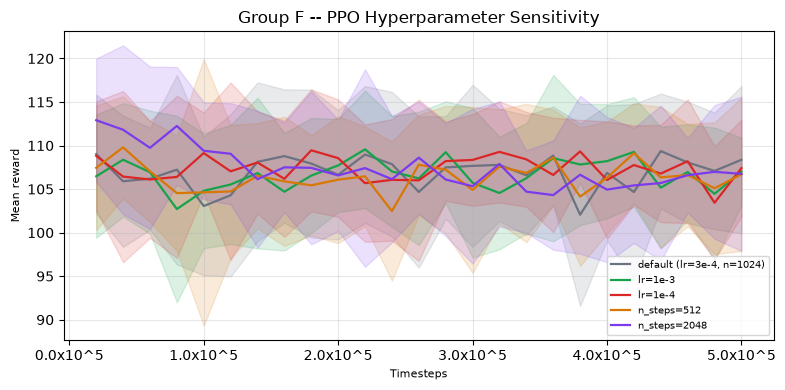

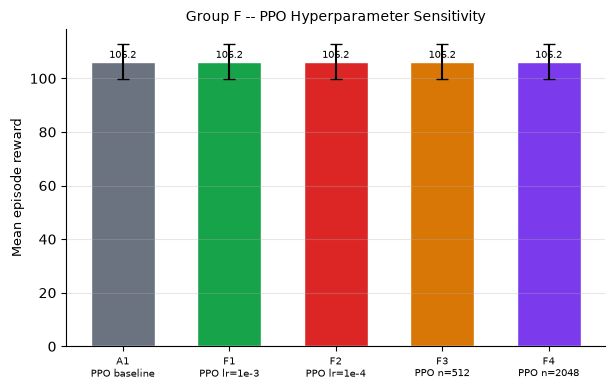

Saved -> output\figures\F_reward_bar.pdf / .png


In [12]:
# CELL 12 — Group F
for eid in ["F1","F2","F3","F4"]:
    trained[eid] = run_experiment(eid)
    res = evaluate_model(trained[eid], eid)
    _store(eid, res)
    print(f"  {eid}  reward={res['mean_reward']:.2f}  crit_unsrv={res['mean_unserved']:.1f}")

GROUP_F_all    = ["A1","F1","F2","F3","F4"]
GROUP_F_labels = {
    "A1": "default (lr=3e-4, n=1024)",
    "F1": "lr=1e-3", "F2": "lr=1e-4",
    "F3": "n_steps=512", "F4": "n_steps=2048",
}
fig, ax = plt.subplots(figsize=(8, 4))
for eid, col in zip(GROUP_F_all, GROUP_COLORS["F"]):
    if eid in trained:
        plot_learning_curve(eid, GROUP_F_labels[eid], ax=ax, color=col)
ax.set_title("Group F -- PPO Hyperparameter Sensitivity")
plt.tight_layout()
for ext in ["pdf","png"]: plt.savefig(FIGURES/f"F_learning_curves.{ext}", bbox_inches="tight", dpi=150)
plt.show()

group_bar_chart(GROUP_F_all, ALL_RESULTS, "reward",
                "Group F -- PPO Hyperparameter Sensitivity", "F_reward_bar",
                ylabel="Mean episode reward", colors=GROUP_COLORS["F"])

In [13]:
# CELL 13 — Greedy baselines
GREEDY_RATES = [1.5, 3.0, 4.5, 6.0]

for lam in GREEDY_RATES:
    g   = evaluate_greedy(arrival_rate=lam, n_episodes=100)
    key = f"Greedy-{lam}"
    ALL_RESULTS[key] = {
        "label":      f"Greedy lam={lam}",
        "reward":     {"mean": g["mean_reward"],     "std": g["std_reward"]},
        "treated":    {"mean": g["mean_treated"],    "std": 0.0},
        "admitted":   {"mean": g["mean_admitted"],   "std": 0.0},
        "redirected": {"mean": g["mean_redirected"], "std": 0.0},
        "unserved":   {"mean": g["mean_unserved"],   "std": 0.0},
    }
    print(f"Greedy lam={lam}  reward={g['mean_reward']:.2f}+/-{g['std_reward']:.2f}"
          f"  admitted={g['mean_admitted']:.1f}  redirected={g['mean_redirected']:.1f}"
          f"  crit_unsrv={g['mean_unserved']:.1f}")

Greedy lam=1.5  reward=206.34+/-40.10  admitted=34.4  redirected=161.7  crit_unsrv=26.0
Greedy lam=3.0  reward=101.03+/-10.13  admitted=35.0  redirected=162.1  crit_unsrv=127.5
Greedy lam=4.5  reward=-35.69+/-91.03  admitted=35.0  redirected=161.9  crit_unsrv=979.8
Greedy lam=6.0  reward=-328.91+/-50.31  admitted=35.0  redirected=162.2  crit_unsrv=2925.1


In [14]:
# CELL 14 — Master results table
ORDER = (
    ["A1","A2","A3"]
  + ["B1","B2","B3","B4","B5","B6","B7","B8","B9"]
  + ["C1","C2","C3","C4","C5","C6","C7","C8","C9"]
  + ["D1","D2","D3","D4","D5","D6"]
  + ["E2","E3"]
  + ["F1","F2","F3","F4"]
  + [f"Greedy-{l}" for l in [1.5, 3.0, 4.5, 6.0]]
)

rows = []
seen = set()
for eid in ORDER:
    if eid in ALL_RESULTS and eid not in seen:
        seen.add(eid)
        r = ALL_RESULTS[eid]
        rows.append({
            "ID":            eid,
            "Condition":     r["label"],
            "Mean Reward":   f"{r['reward']['mean']:.2f}",
            "Std":           f"{r['reward']['std']:.2f}",
            "Admitted/ep":   f"{r.get('admitted',  {'mean':0})['mean']:.1f}",
            "Redirected/ep": f"{r.get('redirected',{'mean':0})['mean']:.1f}",
            "Crit Unserved": f"{r['unserved']['mean']:.1f}",
        })

df = pd.DataFrame(rows)
pd.set_option("display.max_rows", 60)
print(df.to_string(index=False))
csv_path = OUT / "results_master.csv"
df.to_csv(csv_path, index=False)
print(f"\nSaved -> {csv_path}  ({len(rows)} rows)")

        ID      Condition Mean Reward   Std Admitted/ep Redirected/ep Crit Unserved
        A1   PPO baseline      106.17  6.51         0.0         200.0          88.7
        A2   DQN baseline      110.94  8.44        17.6         182.2         102.8
        A3   A2C baseline      106.17  6.51         0.0         200.0          88.7
        B1    PPO lam=1.5      226.48 40.80         0.0         199.4          12.6
        B2    DQN lam=1.5      212.32 35.74        18.3         179.1          39.1
        B3    A2C lam=1.5      230.19 39.59        11.8         187.1          12.8
        B4    PPO lam=4.5       24.80 45.96         7.7         192.2         589.0
        B5    DQN lam=4.5       21.26 59.83        20.4         179.3         633.6
        B6    A2C lam=4.5       18.14 53.12         0.0         200.0         610.3
        B7    PPO lam=6.0     -291.90 68.13        25.0         174.4        2691.4
        B8    DQN lam=6.0     -294.95 56.28        28.6         170.3       

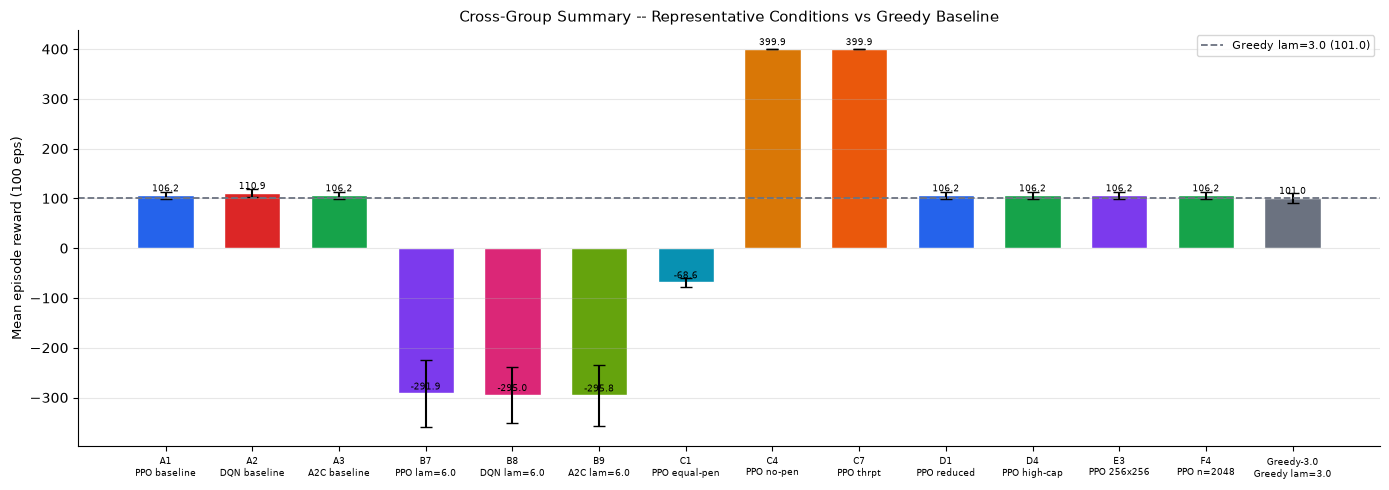

Saved -> output\figures/summary_bar.pdf


In [15]:
# CELL 15 — Summary figure
SUMMARY_PLAN = [
    ("A1","#2563EB"), ("A2","#DC2626"), ("A3","#16A34A"),
    ("B7","#7C3AED"), ("B8","#DB2777"), ("B9","#65A30D"),
    ("C1","#0891B2"), ("C4","#D97706"), ("C7","#EA580C"),
    ("D1","#2563EB"), ("D4","#16A34A"),
    ("E3","#7C3AED"), ("F4","#16A34A"),
    ("Greedy-3.0","#6B7280"),
]

valid  = [(eid,col) for eid,col in SUMMARY_PLAN if eid in ALL_RESULTS]
ids    = [e for e,_ in valid]; cols = [c for _,c in valid]
labels = [ALL_RESULTS[i]["label"]        for i in ids]
means  = [ALL_RESULTS[i]["reward"]["mean"] for i in ids]
stds   = [ALL_RESULTS[i]["reward"]["std"]  for i in ids]

fig, ax = plt.subplots(figsize=(14, 5))
x    = np.arange(len(ids))
bars = ax.bar(x, means, yerr=stds, color=cols, capsize=4,
              edgecolor="white", width=0.65)
for bar, m in zip(bars, means):
    top = bar.get_height() + (max(stds) if stds else 0)*0.05 + 0.2
    ax.text(bar.get_x()+bar.get_width()/2, top,
            f"{m:.1f}", ha="center", va="bottom", fontsize=6.5)
ax.set_xticks(x)
ax.set_xticklabels([f"{i}\n{l}" for i,l in zip(ids,labels)], fontsize=6.5)
gv = ALL_RESULTS.get("Greedy-3.0",{}).get("reward",{}).get("mean",0)
ax.axhline(gv, color="#6B7280", linestyle="--", lw=1.3,
           label=f"Greedy lam=3.0 ({gv:.1f})")
ax.set_ylabel("Mean episode reward (100 eps)", fontsize=9)
ax.set_title("Cross-Group Summary -- Representative Conditions vs Greedy Baseline", fontsize=11)
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
for ext in ["pdf","png"]: plt.savefig(FIGURES/f"summary_bar.{ext}", bbox_inches="tight", dpi=150)
plt.show(); print(f"Saved -> {FIGURES}/summary_bar.pdf")

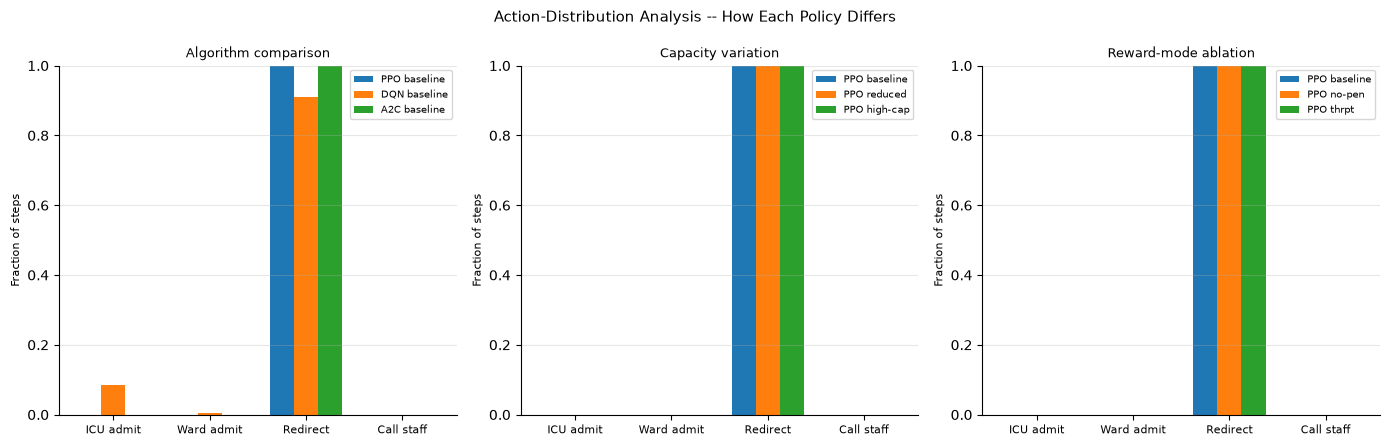

Saved -> output\figures/action_distribution.pdf


In [16]:
# CELL 16 — Action distribution
def action_distribution(model, exp_id: str,
                         n_episodes: int = 50, seed: int = 77) -> np.ndarray:
    _, env_kwargs, _, _, _ = EXPERIMENTS[exp_id]
    env = HospitalEnv(**env_kwargs)
    rng = np.random.default_rng(seed)
    counts = np.zeros(4)
    for _ in range(n_episodes):
        obs, _ = env.reset(seed=int(rng.integers(0, 2**31)))
        done = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            counts[int(action)] += 1
            obs, _, done, _, _ = env.step(int(action))
    return counts / counts.sum()


triplets = [
    ("Algorithm comparison", ["A1","A2","A3"]),
    ("Capacity variation",   ["A1","D1","D4"]),
    ("Reward-mode ablation", ["A1","C4","C7"]),
]
action_labels = ["ICU admit","Ward admit","Redirect","Call staff"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, (title, ids) in zip(axes, triplets):
    dists, lbls = [], []
    for eid in ids:
        if eid in trained:
            dists.append(action_distribution(trained[eid], eid))
            lbls.append(EXPERIMENTS[eid][4].split(" ", 1)[1])
    if not dists: continue
    x = np.arange(4); w = 0.25
    for k, (dist, lbl) in enumerate(zip(dists, lbls)):
        ax.bar(x + k*w, dist, width=w, label=lbl)
    ax.set_xticks(x + w*(len(dists)-1)/2)
    ax.set_xticklabels(action_labels, fontsize=8)
    ax.set_ylabel("Fraction of steps", fontsize=8)
    ax.set_ylim(0, 1); ax.legend(fontsize=7)
    ax.set_title(title, fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)

fig.suptitle("Action-Distribution Analysis -- How Each Policy Differs", fontsize=11)
plt.tight_layout()
for ext in ["pdf","png"]: plt.savefig(FIGURES/f"action_distribution.{ext}", bbox_inches="tight", dpi=150)
plt.show(); print(f"Saved -> {FIGURES}/action_distribution.pdf")